In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt


In [2]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
X, y = make_regression(n_samples=100, n_features=4, noise=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [3]:
# Ridge Regression
class Ridge_reg():
    def __init__(self,alpha=1.0):# alpha is the regularization parameter 
        self.alpha = alpha
        self.b0=None
        self.weight=None
    def fit(self,X,Y):
        x=np.insert(X,0,1,axis=1)
        beta=np.linalg.inv(x.T.dot(x)+self.alpha*np.identity(x.shape[1])).dot(x.T).dot(Y)
        self.b0=beta[0]
        self.weight=beta[1:]
    def predict(self,X):
        return self.b0+X.dot(self.weight)

In [4]:
model=Ridge_reg(alpha=1.0)
model.fit(X_train,y_train)
model.predict(X_test)

array([ -43.07917649,    9.12496719,  106.64308625,  -68.94770648,
       -104.32797852,   93.58170915,  -76.56305711,   52.83018986,
        -20.8032822 ,    3.19302647,  -63.81444019,    3.91493384,
        124.86001327,   69.63235822, -102.98800029, -130.05887111,
        -77.47979414, -139.11871827,   -5.23850433,  -36.33293681])

In [5]:
from sklearn.metrics import r2_score
r2_score(y_test,model.predict(X_test))

0.9330560728029986

Text(0, 0.5, 'R2 Score')

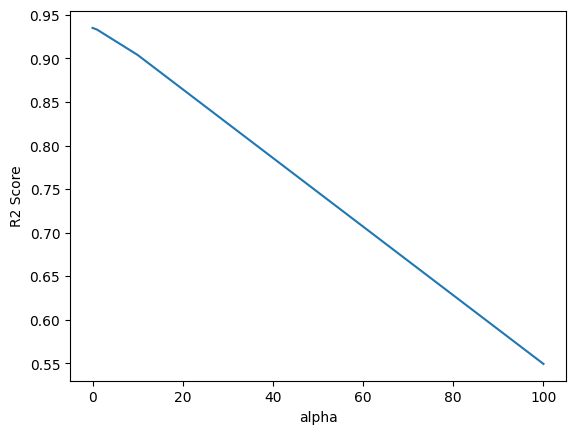

In [6]:
# effect of alpha 
alphas=[0.01,0.1,1,10,100]
r2_scores=[]
for alpha in alphas:
    model=Ridge_reg(alpha=alpha)
    model.fit(X_train,y_train)
    r2_scores.append(r2_score(y_test,model.predict(X_test)))
plt.plot(alphas,r2_scores)
plt.xlabel('alpha')
plt.ylabel('R2 Score')


In [7]:
# effect on weights 
alphas=[0.01,0.1,1,10,100]
for i in alphas:
    model=Ridge_reg(alpha=i)
    model.fit(X_train,y_train)
    print(f'alpha: {i}, weights: {model.weight}')

alpha: 0.01, weights: [86.46275064  5.61911159 28.73317489 36.08245472]
alpha: 0.1, weights: [86.36716426  5.59652958 28.71515781 36.02124026]
alpha: 1, weights: [85.42362428  5.37576475 28.53533004 35.42020532]
alpha: 10, weights: [77.0688033   3.59017711 26.78900919 30.34718378]
alpha: 100, weights: [39.56641839 -0.83561219 15.87658404 12.41540288]


In [11]:
from sklearn.linear_model import Ridge
model=Ridge(alpha=0.01)
model.fit(X_train,y_train)
model.coef_,model.intercept_
y_pred=model.predict(X_test)
